# EEP 595 Homework 3: Identifying Malicious Requests from URLs

Welcome to the third homework of EEP 595! In this homework, we will try to identify malicious HTTP requests from their URLs. Malicious HTTP requests usually target website backends or browsers. Often, their paths contain SQL, HTML or JavaScript fragments so that they can be used to launch script injection attacks. Since these script fragments look considerably different from normal HTTP request URLs, it is possible to tell them apart with a machine learning model.

You may find the goal of this homework similar to the goal of the first homework, where we use classical feature extraction techniques and machine learning models to classify Twitter messages into benign and malicious classes; however, this time we will certainly do it in a different way. To be specific, we will build N-gram embedding from our datasets and also use a neural network to perform HTTP requests URL classification.

## Before You Start

1. You can discuss on Slack if you have questions and want to seek help; however, please try your best to **limit the scope of your question** and **avoid asking directly for answers**. You should also **avoid copy-pasting answers and code** from others.
2. You are allowed to use AI assistants (such as ChatGPT or Google Gemini) for help. In this case, you should **acknowledge your use of AI assistant** by providing its **name as well as how it helps you** to obtain your answer. Again, you **should not copy-paste from the response** of the AI assistant.
3. You can **optionally work on this homework with one other student of this course as a team**, but each of you needs to submit the homework individually. If you choose to form a group, please include the name of your teammate here: _(Name of your teammate)_.

## Set Up Homework Environment

Before starting with the code, install all dependencies needed for this homework by running the cell below:

In [ ]:
%pip install numpy matplotlib pandas tqdm assertpy

# If using Anaconda / Miniconda, install PyTorch with:
# %conda install conda-forge::pytorch-gpu # (CPU and GPU support)
# %conda install conda-forge::pytorch # (CPU-only support)

# If using Pip, install PyTorch with:
%pip install torch
# When installing PyTorch with GPU support, refer to https://pytorch.org/get-started/locally/
# if your CUDA version differs from the default CUDA version of the current version PyTorch package.

## Previewing / Preparing Dataset

As usual, we begin the pre-processing stage by loading the datasets into memory. The WAF URL dataset contains both benign and malicious request URLs. Benign URLs are labeled as `False` and malicious URLs are labeled as `True`:

In [ ]:
import pandas as pd

waf_urls_dataset = pd.read_csv("./waf-urls.csv")
# Preview the dataset
print(waf_urls_dataset)

The first step of feature extraction stage involves **splitting all samples** (URLs and labels) into training (**60%**), validation (**20%**) and test (**20%**) sets:

In [ ]:
from sklearn.model_selection import train_test_split

# Split URLs and labels into training, validation and test sets
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    waf_urls_dataset["url"].tolist(),
    waf_urls_dataset["label"].values,
    test_size=0.2,
    random_state=12345
)

urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345
)

## Building N-Gram Mappings

Like the first homework, we will extract the features of URLs by splitting them into series of **character N-grams**, which are sequences of N consecutive characters. Below is an example for the unigrams ($N = 1$), bigrams ($N = 2$), trigrams ($N = 3$) and 4-grams ($N = 4$) of word "cold":

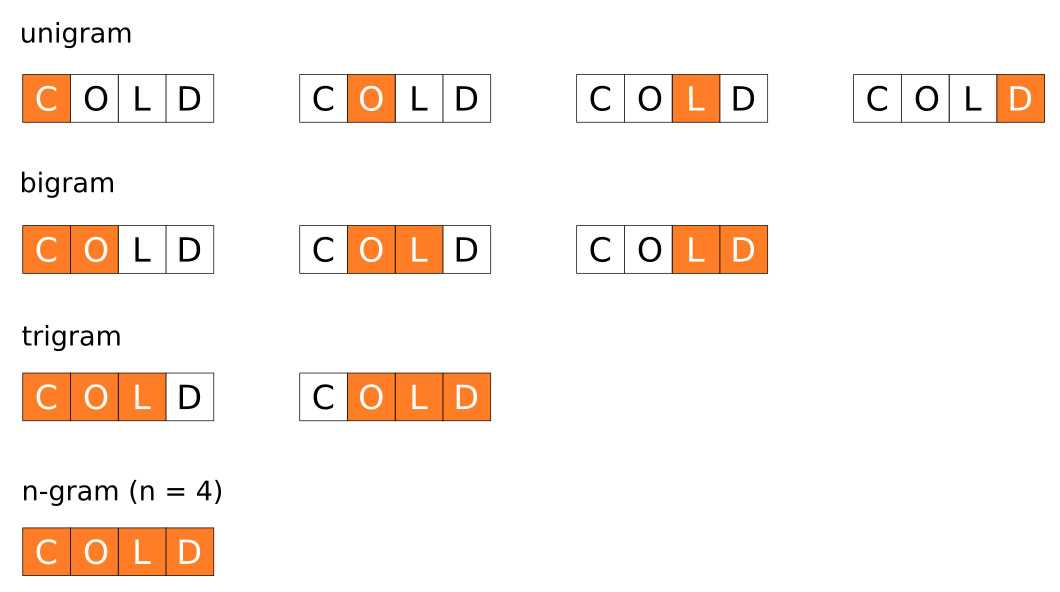

In the first homework, generation and counting of N-grams are done by using `CountVectorizer` and `TfidfVectorizer` from `sklearn`. This time, however, we will generate N-grams on our own using an `iter_ngrams` function which does the following things:

1. Suppose `text` is the URL string and `n` is the length of the N-gram. `iter_ngrams` will pad `n-1` `start_symbol` before the URL and `n` `end_symbol` after the URL. `start_symbol` and `end_symbol` are special **characters** that will not clash with any characters inside the URLs.

   **Example**: "/test" should become `<S><S>/test<E><E><E>` after padding when $N = 3$.

2. `iter_ngrams` then generates N-grams from the padded URLs.

   **Example**: "/test" should produce trigrams `<S><S>/`, `<S>/t`, `/te`, `tes`, `est`, `st<E>`, `t<E><E>` and `<E><E><E>`.

We have provided you with two tests right below the `iter_ngrams` for you to examine the correctness of your implementation.

In [ ]:
from assertpy import assert_that

def iter_ngrams(text, n, start_symbol="\x00", end_symbol="\x01"):
    """ Returns an iterable that yields all N-grams of the text with start and end padding. """
    ## [ TODO ]
    # Implement N-grams generation with start and end padding
    # (Note: start and end symbols are ALWAYS characters)
    # (Hint: pad `n-1` start symbols to the start and `n` end symbols to the end)
    raise NotImplementedError

# Test case for "/test" (N = 3)
assert_that(list(iter_ngrams("/test", n=3))).is_equal_to([
    "\x00\x00/", "\x00/t", "/te", "tes", "est", "st\x01", "t\x01\x01", "\x01\x01\x01"
])
# Test case for "/nested/2" (N = 4)
assert_that(list(iter_ngrams("/nested/2", n=4))).is_equal_to([
    "\x00\x00\x00/", "\x00\x00/n", "\x00/ne", "/nes", "nest", "este", "sted", "ted/",
    "ed/2", "d/2\x01", "/2\x01\x01", "2\x01\x01\x01", "\x01\x01\x01\x01"
])

Next, we will **build a bidirectional mapping** for all unique N-grams occurring in our dataset. The function responsible for this step is the following `build_ngram_mapping` function, which takes a list of `urls`, `n` as in N-grams and a `rare_threshold` under which an N-gram will be marked as rare and discarded. Again, we use an example here to show how it works:

* Let's assume $N = 3$ and `urls` contains 3 URLs: "/x", "/xyz/23" and "/233".
* We first **generates trigrams** for all 3 URLs, and here's the result:

  1. "/x": `<S><S>/`, `<S>/x`, `/x<E>`, `x<E><E>` and `<E><E><E>`.
  2. "/xyz/23": `<S><S>/`, `<S>/x`, `/xy`, `xyz`, `yz/`, `z/2`, `/23`, `23<E>`, `3<E><E>` and `<E><E><E>`.
  3. "/233": `<S><S>/`, `<S>/2`, `/23`, `233`, `33<E>`, `3<E><E>` and `<E><E><E>`.

* Now we **count the occurrences of all unique trigrams in all URLs in order**. In the end, we would obtain the following count table:

|Trigram    |Count|Trigram    |Count|
|-----------|-----|-----------|-----|
|`<S><S>/`  |3    |`z/2`      |1    |
|`<S>/x`    |2    |`/23`      |2    |
|`/x<E>`    |1    |`23<E>`    |1    |
|`x<E><E>`  |1    |`3<E><E>`  |2    |
|`<E><E><E>`|3    |`<S>/2`    |1    |
|`/xy`      |1    |`233`      |1    |
|`xyz`      |1    |`33<E>`    |1    |
|`yz/`      |1    |-          |-    |


* For each rare trigram (that is, the occurrence count of the N-gram is **smaller than** `rare_threshold`), we **discard it from the count table**. Here let's set `rare_threshold` to 2, and we will obtain:

|Trigram    |Count|
|-----------|-----|
|`<S><S>/`  |3    |
|`<S>/x`    |2    |
|`<E><E><E>`|3    |
|`/23`      |2    |
|`3<E><E>`  |2    |

* After discarding rare trigrams, we **give each trigram a self-increasing index in order**. This establishes a bidirectional mapping between trigrams and numerical indices. We store the mapping from trigrams to indices (`n2i_mapping`) in a dictionary, and the reverse mapping from indices to trigrams (`i2n_mapping`) in a list:

|Trigram    |Index|
|-----------|-----|
|`<S><S>/`  |0    |
|`<S>/x`    |1    |
|`<E><E><E>`|2    |
|`/23`      |3    |
|`3<E><E>`  |4    |

* In the end, `build_ngram_mapping` returns both `n2i_mapping` and `i2n_mapping`, and their content should be:
  1. `n2i_mapping`: `{"<S><S>/": 0, "<S>/x": 1, "<E><E><E>": 2, "/23": 3, "3<E><E>": 4}`
  2. `i2n_mapping`: `["<S><S>/", "<S>/x", "<E><E><E>", "/23", "3<E><E>"]`

Like `iter_ngrams`, this example is provided to you below to test the correctness of your `build_ngram_mapping` implementation.

In [ ]:
from tqdm import tqdm

def build_ngram_mapping(urls, n, rare_threshold=2):
    """ Build bidirectional N-gram to numerical index mapping, ignoring rare N-grams. """
    # N-gram occurrences count
    ngram_count = {}
    
    print("Counting occurrences for unique N-grams...", flush=True)
    ## [ TODO ]
    # 1) Count occurrence for every N-gram in every URL
    #    (store results in `ngram_count`)
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            raise NotImplementedError
    
    # N-gram to index mapping
    n2i_mapping = {}
    # Index to N-gram mapping
    i2n_mapping = []
    
    # Total occurrence of all N-grams
    n_occurrence = sum(ngram_count.values())
    # Total occurrence of rare N-grams
    n_occurrence_rare = 0
    
    print("Building bidirectional N-gram to numerical index mapping...", flush=True)
    ## [ TODO ]
    # 2) Build bidirectional N-gram to index mapping (`n2i_mapping` and `i2n_mapping`)
    #    (Note: only add N-gram to mapping if it appears NO LESS THAN `rare_threshold` times!)
    #    (Note: if an N-gram is rare, increase `n_occurrence_rare` by one)
    for ngram, count in tqdm(ngram_count.items()):
        raise NotImplementedError
    
    # Rare occurrence percentage
    rare_occurrence_pc = n_occurrence_rare/n_occurrence*100
    
    # Total number of unique N-grams
    n_ngram = len(ngram_count)
    # Total number of unique rare N-grams
    n_ngram_rare = n_ngram-len(i2n_mapping)
    # Rare unique N-grams percentage
    rare_ngram_pc = n_ngram_rare/n_ngram*100
    
    # Print occurrence and unique N-grams metrics
    print(f"Total occurrence: {n_occurrence} ({n_occurrence_rare} rare, {rare_occurrence_pc:.2f}%)")
    print(f"Unique N-grams: {n_ngram} ({n_ngram_rare} rare, {rare_ngram_pc:.2f}%)")
    
    # Return bidirectional mappings
    return n2i_mapping, i2n_mapping

In [ ]:
# Bidirectional mapping for implementation testing URLs
n2i_impl_test, i2n_impl_test = build_ngram_mapping(["/x", "/xyz/23", "/233"], n=3)

# Check N-gram to index mapping
assert_that(n2i_impl_test).is_equal_to({
    "\x00\x00/": 0,
    "\x00/x": 1,
    "\x01\x01\x01": 2,
    "/23": 3,
    "3\x01\x01": 4
})
# Check index to N-gram mapping
assert_that(i2n_impl_test).is_equal_to([
    "\x00\x00/", "\x00/x", "\x01\x01\x01", "/23", "3\x01\x01"
])

## Building Co-occurrence Matrix

Now entering the most important step of our feature extraction process: we are going to **build a co-occurrence matrix** for all unique N-grams. This is done by the `build_occurrence_matrix` below, which takes a list of `urls`, `n` as in N-grams, the `n2i_mapping` we have generated from the last step and a `window_size` parameter. We reuse the previous example to explain how to build such a matrix:

* From the previous example, `urls` contains "/x", "/xyz/23" and "/233". The bidirectional N-gram mapping generated from the last step is:

|Trigram    |Index|
|-----------|-----|
|`<S><S>/`  |0    |
|`<S>/x`    |1    |
|`<E><E><E>`|2    |
|`/23`      |3    |
|`3<E><E>`  |4    |

* Again, we generates N-gram for all 3 URLs, but we **replace rare N-grams (which do not appear in `n2i_mapping`) with a special unknown token `<U>`**. Here we show the N-grams that are replaced:

  1. "/x": `<S><S>/`, `<S>/x`, ~~`/x<E>`, `x<E><E>`~~ and `<E><E><E>`.
  2. "/xyz/23": `<S><S>/`, `<S>/x`, ~~`/xy`, `xyz`, `yz/`, `z/2`~~, `/23`, ~~`23<E>`~~, `3<E><E>` and `<E><E><E>`.
  3. "/233": `<S><S>/`, ~~`<S>/2`~~, `/23`, ~~`233`, `33<E>`~~, `3<E><E>` and `<E><E><E>`.

* We **create an empty sparse matrix** to hold the count of N-gram co-occurrences. The shape of the matrix is `(n_ngram+1, n_ngram+1)` where `n_ngram` is the number of N-grams in the bidirectional mapping. In this example we have 5 trigrams in the mapping so the shape would be `(6, 6)`. Let's call this co-occurrence matrix `co_count`.

* We now iterate through all N-gram sequences of all URLs **in order**. For each N-gram, we look at its previous neighbors, up to the amount of `window_size`. In our example, let's assume `window_size` is 3. Here we show the neighboring N-grams windows for `cn<E>` and `g.c` in "g.cn":

  ```
  Trigrams of "/x": "<S><S>/", "<S>/x", "<U>", "<U>", "<E><E><E>"
                    |-------|
                    |Window of "<S>/x"
                               |-------------------|
                               |Window of "<E><E><E>"
  ```
  
  To update the co-occurrence count, we iterate through all previous neighboring N-grams **in window** for the current N-gram. This gives a pair of the current N-gram and one previous N-gram `(ngram_current, ngram_prev)`. We then look up for their indices, `index_current` and `index_prev`, in `n2i_mapping`. In case an N-gram is `<U>` its corresponding index will be `n_ngram`. Finally, we update both `co_count[index_current, index_prev]` and `co_count[index_prev, index_current]` by increasing their values by one:
  
  ```
                                 /--> "<S>/x" -----------> (2, 1) --------------|--> co_count[2, 1] += 1
                                 |                                              \--> co_count[1, 2] += 1
  "<E><E><E>" -------------------|--> "<U>" -------------> (2, 5) --------------|--> co_count[2, 5] += 1
              Neighboing N-grams |                                              \--> co_count[5, 2] += 1
                                 \--> "<U>" -------------> (2, 5) --------------|--> co_count[2, 5] += 1 
                                            Index look-up         Co-occurrence \--> co_count[5, 2] += 1 
                                                                  update
  ```

* Before returning the co-occurrence matrix, we need to normalize it by **converting the frequencies** of co-occurrence **into valid probability distributions**. This is done by summing the matrix in the row direction and then divide each row by the corresponding sum of each row. Due to the limitation of SciPy's sparse matrices, you may want to perform the division on elements one-by-one rather using broadcasting rules.

The above example is provided to you as a test of your `build_cooccurrence_matrix` implementation.

In [ ]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """ Build co-occurrence matrix for character N-grams from URLs. """
    # Number of unique N-grams / index for unknown symbol
    n_ngram = unknown_index = len(n2i_mapping)
    # Co-occurrence matrix (DOK sparse matrix)
    cooccurrence_matrix = dok_matrix((n_ngram+1, n_ngram+1))
    
    print(f"Counting co-occurrence of N-grams (n = {n})...", flush=True)
    # Co-occurrence counting loop
    for url in tqdm(urls):
        # Previous neighboring N-gram indices for current URL
        prev_ngram_indices = []
        
        for ngram in iter_ngrams(url, n):
            ## [ TODO ]
            # 1) Get index for current N-gram from mapping
            #    (Hint: set `ngram_index` to `unknown_index` if it is not find in mapping)
            ngram_index = NotImplemented
            
            # 2) Update co-occurrence matrix for previous neighboring N-grams in window
            raise NotImplementedError
            
            # Add current N-gram index
            prev_ngram_indices.append(ngram_index)

    print("Normalizing co-occurrence frequencies...", flush=True)
    # Sum of co-occurrence frequencies
    cooccurrence_sum = cooccurrence_matrix.sum(-1)
    ## [ TODO ]
    # 3) Normalize co-occurrence frequencies into distributions for each row
    for i, j in tqdm(cooccurrence_matrix.keys()):
        raise NotImplementedError
    
    print("Completed.")
    # Return co-occurrence matrix
    return cooccurrence_matrix

In [ ]:
from numpy.testing import assert_array_equal

# Co-occurrence matrix on test URLs
cooccurrence_test = build_cooccurrence_matrix(
    ["/x", "/xyz/23", "/233"],
    n=3,
    n2i_mapping=n2i_impl_test,
    window_size=3
)

# Check result of co-occurrence matrix
assert_array_equal(cooccurrence_test.toarray(), [
    # `<S><S>/` (0)
    [0, 2/9, 0, 1/9, 0, 2/3],
    # `<S>/x` (1)
    [1/4, 0, 1/8, 0, 0, 5/8],
    # `<E><E><E>` (2)
    [0, 1/9, 0, 1/9, 2/9, 5/9],
    # `/23` (3)
    [1/11, 0, 1/11, 0, 2/11, 7/11],
    # `3<E><E>` (4)
    [0, 0, 1/4, 1/4, 0, 1/2],
    # `<U>` (Unknown token) (5)
    [2/17, 5/51, 5/51, 7/51, 4/51, 8/17]
])

OK, with both `build_ngram_mapping` and `build_coocurrence_matrix`, we can now build a real co-occurrence matrix for all URLs in this homework. Different from the settings of previous examples, we will use **4-grams and set the window size to 5** for co-occurrence counting, so please make sure **your code is not hardcoded to handle any particlar N value**. Depending on the speed of your computer, the following code **might take from 5 minutes to half an hour**:

In [ ]:
# N of N-grams
N = 4
# Window size for building co-occurrence matrix
WINDOW_SIZE = 5

# Build bidirectional N-gram mapping for all URLs
n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
# Build co-occurrence matrix for character N-grams from URLs
cooccurrence_urls = build_cooccurrence_matrix(
    urls_train, N, n2i_mapping=n2i_urls, window_size=WINDOW_SIZE
)

# Review co-occurrence matrix
print(type(cooccurrence_urls), cooccurrence_urls.shape)

The final step of N-gram feature generation involves dimensionality reduction. We will use the [`TruncatedSVD` algorithm](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) to **reduce the dimensions of the co-occurrence matrix** in order to create an **[embedding](https://en.wikipedia.org/wiki/Word_embedding)** for every unique N-gram. Later you will see that we will replace the occurrence of N-grams with their corresponding embedding vectors during the training of the classification neural network.

In [ ]:
from sklearn.decomposition import TruncatedSVD

# Number of embedding dimensions
EMBEDDING_DIMS_SVD = 10

## [ TODO ]
# 1) Create a truncated SVD model that reduces features to `EMBEDDING_DIMS_SVD` dimensions
#    (Hint: fix the random seed and choose the number of iterations as you like)
# 2) Perform dimensionality reduction on `cooccurrence_urls` to obtain embedding for N-grams,
#    name the embedding `embedding_svd`
embedding_svd = NotImplemented

assert_that(embedding_svd.shape).is_equal_to(
    (len(n2i_urls)+1, EMBEDDING_DIMS_SVD)
)

## Training

We begin the training stage by **building a neural network model for classification**. The neural network is a [Convolutional Neural Network](https://en.wikipedia.org/wiki/Convolutional_neural_network) that utilizes [one-dimensional convolution and max pooling layers](https://pytorch.org/docs/stable/nn.html#convolution-layers) because our inputs are one-dimensional sequences rather than two-dimensional images. It also includes an [embedding layer](https://pytorch.org/docs/stable/nn.html#torch.nn.Embedding) that accepts sequences of N-gram indices and outputs the look-up results of N-gram embedding vectors. Below is an illustration of 1D convolution and max pooling layers:

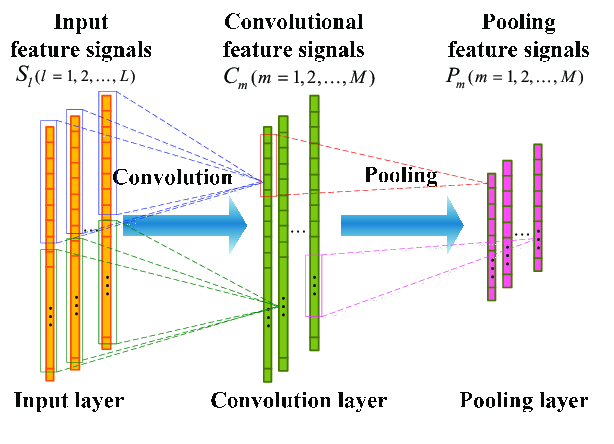

In [ ]:
import torch
from torch import nn
from torch.nn import functional as f

## [ TODO ]
# Define the CNN model for URL classification
# (If you are not satisfied with the following structure of the neural network,
#  feel free to change it, but please describe your changes in details)
#
# You can implement this model using either:
#   - `torch.nn.Sequential` with all layers in order
#   - A custom class that inherits from `torch.nn.Module` with __init__ and forward methods
#
# 1) Embedding layer: (*, padded_len+n) -Embedding-> (*, padded_len+n, embedding_dims)
#    - Initialize torch.nn.Embedding with:
#      a) Number of input dimensions (vocabulary size): `n_ngram+1`
#      b) Number of output dimensions (embedding size): `embedding_dims`
#      c) Initialize weights with `embedding_weights` using the `_weight` attribute
#      d) Disable gradient computation with `requires_grad=False`
# 2) Transpose for channel-first format: (*, padded_len+n, embedding_dims) -> (*, embedding_dims, padded_len+n)
#    - PyTorch Conv1d expects channels as the second dimension (channel-first format)
#    - Use transpose or permute to rearrange dimensions
# 3) First convolution block: (*, embedding_dims, padded_len+n) -Conv1d+ReLU-> (*, 20, padded_len+n) -MaxPool1d-> (*, 20, padded_len+n//2)
#    - Conv1d layer: 20 output channels, kernel size 5, padding 2
#    - Activation: ReLU
#    - MaxPool1d layer: kernel size 2, stride 2
# 4) Second convolution block: (*, 20, padded_len+n//2) -Conv1d+ReLU-> (*, 40, padded_len+n//2) -MaxPool1d-> (*, 40, padded_len+n//10)
#    - Conv1d layer: 40 output channels, kernel size 5, padding 2
#    - Activation: ReLU
#    - MaxPool1d layer: kernel size 5, stride 5
# 5) Third convolution block: (*, 40, padded_len+n//10) -Conv1d+ReLU-> (*, 80, padded_len+n//10) -MaxPool1d-> (*, 80, padded_len+n//50)
#    - Conv1d layer: 80 output channels, kernel size 5, padding 2
#    - Activation: ReLU
#    - MaxPool1d layer: kernel size 5, stride 5
# 6) Flatten: (*, 80, padded_len+n//50) -> (*, flattened_size)
#    - Calculate flattened_size: (padded_len + n) // (2 * 5 * 5) * 80
#    - Use view or reshape to flatten all dimensions except batch
# 7) First fully-connected layer: (*, flattened_size) -Linear+ReLU+Dropout-> (*, 16)
#    - Linear layer with input size `flattened_size` and output size 16
#    - Activation: ReLU
#    - Dropout layer with probability `dropout_ratio`
# 8) Second fully-connected layer: (*, 16) -Linear-> (*, 1)
#    - Linear layer with input size 16 and output size 1
#    - No activation (output logits for binary cross-entropy loss)
# 9) Squeeze final dimension: (*, 1) -> (*)
#    - Remove the extra dimension to produce a single logit per sample
#    - Use squeeze or reshape to reduce dimensions

Note that the neural network model takes **sequences of N-gram indices** rather than raw URLs as an input. Thus an extra function, `transform_urls`, is needed to **perform convertion between the two formats**:

1. For each URL, we **pad extra `pad_symbol`s** at the end so that the length of every padded URL is always `padded_len`.
2. We then **extract all N-grams** for the padded URL. For a single padded URL we are guaranteed to obtain `padded_len+n` N-grams.
3. For each N-gram, we **look up for its corresponding index** in `n2i_mapping`. If an N-gram is not found then we set the index to the index for unknown symbol, which is `unknown_index` (equal to `n_ngram` or `len(n2i_mapping)`).
4. Finally, we **store the N-gram indices sequence** for the URL at corresponding location.

A test case is provided to you below to ensure the correctness of your `transform_urls` implementation. The test case reuse the trigram to index mapping in the example shown above.

In [ ]:
import numpy as np

def transform_urls(batch_urls, padded_len, n, n2i_mapping, pad_symbol="\x01"):
    # Batch size
    batch_size = len(batch_urls)
    # Batch input to the classification model
    batch_input = np.empty((batch_size, padded_len+n), dtype=int)
    
    # Index for unknown symbol
    unknown_index = len(n2i_mapping)
    
    for i, url in enumerate(batch_urls):
        ## [ TODO ]
        # 1) Pad `url` to `padded_len`
        raise NotImplementedError
        
        # 2) Look up the index of each N-gram in the mapping
        #    (Note: use `unknown_index` if the N-gram is not found in mapping)
        # 3) Save the index to position (i, j) of `batch_input`
        for j, ngram in enumerate(iter_ngrams(url, n)):
            raise NotImplementedError
    
    return batch_input

In [ ]:
# Transform two test URLs
transform_result_test = transform_urls(
    ["/x", "/233"],
    padded_len=4,
    n=3,
    n2i_mapping=n2i_impl_test
)

# Transformation result should be an array
assert_that(transform_result_test).is_instance_of(np.ndarray)
# Check transformation result
assert_array_equal(transform_result_test, [
    [0, 1, 5, 5, 2, 2, 2],
    [0, 5, 3, 5, 5, 4, 2]
])

We would like our training process to apply `transform_urls` to all URLs in the training and validation set. To achieve this, we will wrap our training and validation set in a `URLDataset`, which implements the [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) interface and automatically performs conversion of URLs whenever a new sample is needed for training:

In [ ]:
from torch.utils.data import Dataset

class URLDataset(Dataset):
    """
    PyTorch Dataset wrapper that performs URL-to-N-gram-index conversion on the fly.
    
    This dataset transforms URL strings to N-gram index sequences and pairs them
    with their corresponding labels for training.
    """
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        """
        Args:
            urls: Sequence of URL strings
            labels: Series/array of binary labels (benign=0, malicious=1)
            padded_len: Maximum length of padded URLs
            n: N-gram size
            n2i_mapping: Dictionary mapping N-grams to indices
        """
        self.urls = urls
        self.labels = labels
        self.padded_len = padded_len
        self.n = n
        self.n2i_mapping = n2i_mapping
    
    def __len__(self):
        return len(self.urls)
    
    def __getitem__(self, idx):
        # Transform URL to N-gram index sequence
        urls = [self.urls[idx]]
        transformed_urls = transform_urls(urls, self.padded_len, self.n, self.n2i_mapping)
        url_tensor = torch.as_tensor(transformed_urls[0])

        # Convert label to PyTorch tensor
        label_tensor = torch.tensor(self.labels[idx])
        
        return url_tensor, label_tensor

We also need to implement our PyTorch training loop. Its structure is fairly similar to the ones you saw in previous labs and homeworks, except we are merging the common steps for both training and validation here:

In [ ]:
from torch.utils.data import DataLoader
from tqdm import tqdm

def get_torch_device():
    """
    Detect and return the best available PyTorch device.
    Prefers GPU devices (CUDA or MPS) over CPU.
    """
    # Use CUDA (Nvidia/AMD GPU) if available
    if torch.cuda.is_available():
        device = "cuda"
    # Use MPS (Apple Silicon GPU) if available
    elif torch.backends.mps.is_available():
        device = "mps"
    # Fallback to CPU
    else:
        device = "cpu"
    
    return torch.device(device)

def train_model(model, optimizer, dataset_train, dataset_vali, batch_size=256, n_epochs=10, device=None):
    """
    Train the URLClassificationCNN model using PyTorch with progress tracking.
    
    Args:
        model: URLClassificationCNN instance
        optimizer: PyTorch optimizer instance
        dataset_train: Training URLDataset
        dataset_vali: Validation URLDataset
        batch_size: Batch size for training (default 256)
        n_epochs: Number of training epochs (default 10)
        device: torch.device (cuda, mps, or cpu). Auto-detected if None.
    
    Returns:
        List of dictionaries containing epoch, loss, accuracy, val_loss, val_accuracy for each epoch
    """
    # Detect device from model parameters if not provided
    device = device or next(iter(model.parameters())).device
    
    # Create training and validation data loaders
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    loader_vali = DataLoader(dataset_vali, batch_size=batch_size)
    
    # Initialize history list to track metrics per epoch
    history = []
    
    for epoch in range(n_epochs):
        epoch_history = {}

        print(f"Starting epoch {epoch+1}/{n_epochs} ...")

        for phase, dataset, loader in (
            ("training", dataset_train, loader_train),
            ("validation", dataset_vali, loader_vali)
        ):
            loss_epoch = 0.
            n_correct_epoch = 0.

            # Put model in validation model
            if phase=="validation":
                model.eval()
        
            for urls, labels in tqdm(loader):
                # Move data to target device
                urls = urls.to(device)
                labels = labels.to(device)
                
                # Run the model and compute binary cross entropy loss
                outputs = model(urls)
                predictions = (outputs.detach()>0).long()
                loss = f.binary_cross_entropy_with_logits(outputs, labels.float())

                # During training, compute gradient and take an optimizer step
                if phase=="training":
                    loss.backward()
                    optimizer.step()
                    optimizer.zero_grad()
                
                # Accumulate loss and number of correctly predicted samples
                loss_epoch += loss.detach().item()*len(urls)
                n_correct_epoch += (predictions==labels).sum().item()
            
            # Restore model to training mode
            if phase=="validation":
                model.train()
            
            # Compute average loss and accuracy
            loss_epoch = loss_epoch/len(dataset)
            accuracy = n_correct_epoch/len(dataset)

            # Print and save metrics
            print(f"Done with {phase}. Metrics: loss: {loss_epoch}, accuracy: {accuracy}")

            epoch_history[phase+"_metrics"] = {
                "loss": loss_epoch,
                "accuracy": accuracy
            }
        
        print()
        
        history.append(epoch_history)
    
    return history

Now it's time to put everything together! We will build a classification model which we implemented above, create `URLDataset` objects for both the training and validation sets, and then train our model using the `train_model` function:

In [ ]:
from torch.optim import AdamW

# N as in N-grams
N = 4
# Maximum URL length
MAX_URL_LEN = 96

# Create PyTorch datasets
dataset_train = URLDataset(
    urls_train,
    labels_train,
    padded_len=MAX_URL_LEN,
    n=N,
    n2i_mapping=n2i_urls
)
dataset_vali = URLDataset(
    urls_vali,
    labels_vali,
    padded_len=MAX_URL_LEN,
    n=N,
    n2i_mapping=n2i_urls
)

# [ TODO ]
# Build a basic URL classifier model using your own implementation
embedding_svd_tensor = torch.tensor(embedding_svd, dtype=torch.float32)
model_basic = NotImplemented
# Put model on target device
torch_device = get_torch_device()
model_basic = model_basic.to(torch_device)

# Build optimizer
optimizer = AdamW(model_basic.parameters(), lr=0.005)

# Train the basic model for 10 epochs
history_basic = train_model(
    model_basic,
    optimizer,
    dataset_train,
    dataset_vali,
    batch_size=256,
    n_epochs=10
)

## Evaluation

Like homework 2, we start the evaluation stage by **plotting the loss and accuracy** of each epoch on both the training and the validation set. The `history_basic` list stores one dictionary per epoch, where each dictionary contains `"training_metrics"` and `"validation_metrics"` keys:

In [ ]:
from matplotlib import pyplot as plt

def plot_metric(history, metric_name, y_label, title=None, ax=None):
    """ Plot training and validation metrics for all epochs. """
    # Default subplot
    if ax is None:
        ax = plt.gca()
    # Title defaults to Y label name
    if title is None:
        title = y_label
    
    # Training and validation metrics
    train_metrics = [h["training_metrics"][metric_name] for h in history]
    vali_metrics = [h["validation_metrics"][metric_name] for h in history]
    # Epochs
    epochs = np.arange(1, len(train_metrics) + 1, dtype=int)
    
    # Plot training and validation metrics
    ax.plot(epochs, train_metrics, label="Training")
    ax.plot(epochs, vali_metrics, label="Validation")
    # Set X and Y label
    ax.set_xlabel("Epoch")
    ax.set_ylabel(y_label)
    # Set title
    ax.set_title(title)
    # Show grid and add legend
    ax.grid()
    ax.legend(fancybox=True, framealpha=0.8)

In [ ]:
# Create a figure for plotting metrics for basic model
fig_basic = plt.figure(figsize=(20, 6))

## [ TODO ]
# Plot the accuracy and loss of each epoch on both training and validation set
# (Caution: plot the same metric of both sets on the same plot)
raise NotImplementedError

Next, we will evaluate the performance of the whole pipeline (rather than just the neural network model) on the test set:

* We start with **transforming the test URLs into N-gram index sequences** by calling the `transform_urls` function. Except we are transforming all URLs at once, all other parameters of the `transform_urls` function remain the same.
* The N-gram index sequences are then **fed into the neural network model**, which outputs log probabilities (logits) of whether each URL is malicious or not.
* The output log probabilities (logits) are then **converted into binary predictions** by applying a 0 threshold: predictions greater than 0 are labeled as malicious (1), and predictions less than or equal to zero are labeled as benign (0).
* Finally, with both predictions and actual labels, we **generate the [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) and [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)** for the result on the test set.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO ]
# 1) Use `transform_urls` to convert test URLs into N-gram index sequences
transformed_urls_test = NotImplemented

# Convert to PyTorch tensor
urls_test_tensor = torch.tensor(transformed_urls_test, device=torch_device)
# Predict results for test URLs
with torch.inference_mode():
    outputs_test = model_basic(urls_test_tensor)

## [ TODO ]
# 2) Convert neural network predictions back to labels
# 3) Print confusion matrix and classification report of the test set predictions
#    (Hint: test labels are available in `labels_test`)
raise NotImplementedError

## Questions

1. Analyze the performance of the malicious URL identification model with precision, recall and f1-score. For this particular task, does lower loss indicate higher accuracy? If it does, do you think this will also hold for general cases? Justify your answers with reasons and examples.

2. When computing the co-occurrence matrix of N-grams, is it good to use a large window size (e.g. `window_size = 50` instead of `3`)? Can you come up with another method to "compress" the co-occurrence matrix into N-gram embeddings? (Note: you are NOT REQUIRED to run or provide any code in order to answer this question)

## OPTIONAL: Training and Generating Ngram2Vec Embeddings

**(Note: This part is optional and will not graded; however, upon your request we can give you feedbacks if you choose to do the following additional task)**

In the previous part of this homework, we have computed the co-occurrence matrix for all unique N-grams from the URLs and used [`TruncatedSVD` algorithm](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) to perform dimensionality reduction. The resulting "compressed" features are then used as the embedding vectors for all N-grams in the neural network model. In this improvement task, we will **use a special neural network to perform dimensionality reduction** instead and obtain **an alternative embedding** named _Ngram2Vec_. This neural network is very similar, but not identical, to the autoencoder neural networks we have been talking about in the previous lab.

The _Ngram2Vec_ embedding is based on the [Word2Vec](https://en.wikipedia.org/wiki/Word2vec) embedding, both of which make use of a three-layer, autoencoder-like neural network:

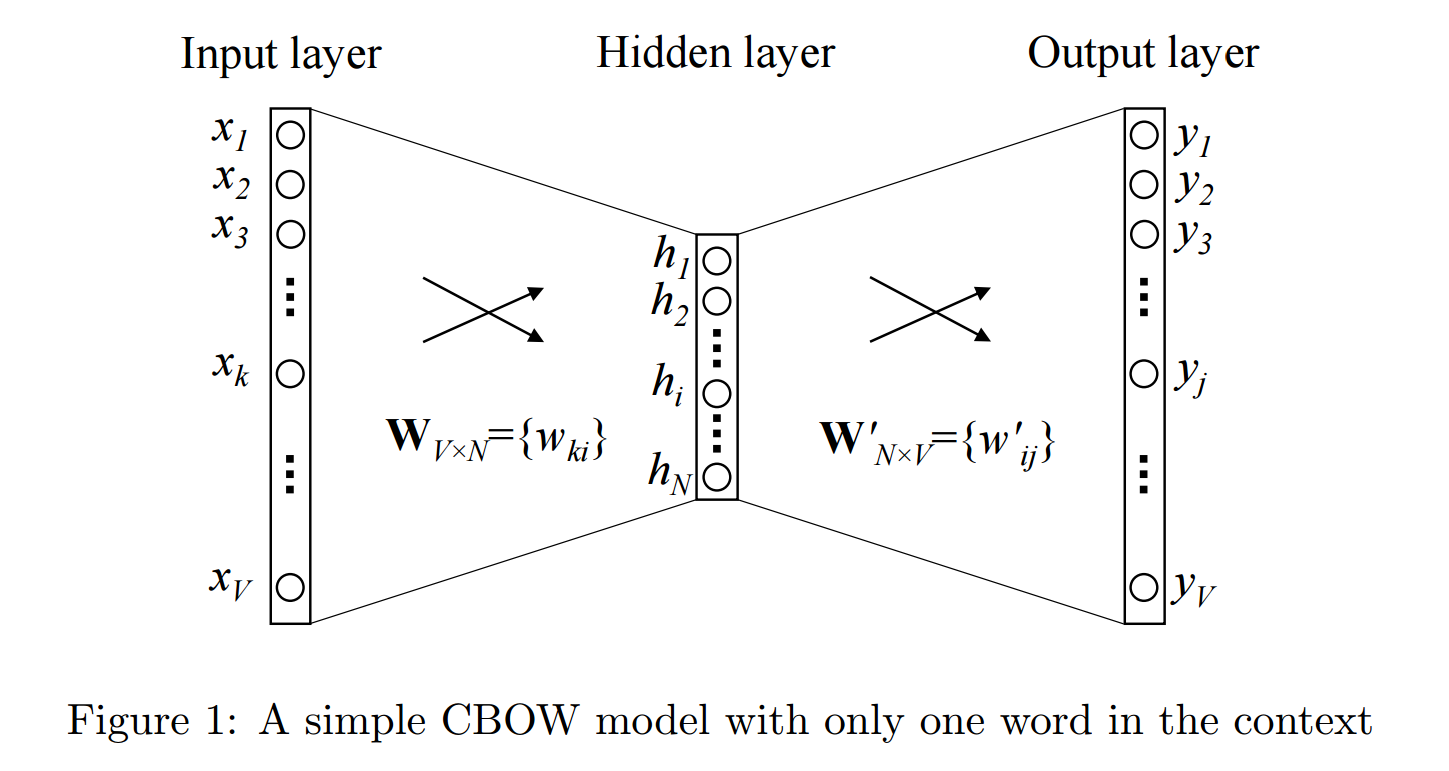

Both the input (first) layer and output (last) layer has `n_ngram+1` layers, where `n_ngram` represents the number of unique N-grams and the last neuron represents the special unknown (`<U>`) token. Like the autoencoder, the hidden layer contains `n_embedding` layers and serves as the bottleneck of the neural network for information compression purposes.

During training of the _Ngram2Vec_ network, we randomly choose a number of unique N-grams each time and one-hot encode them as the inputs of the neural network. We also look up for the co-occurrence probability distributions for these N-grams in the co-occurrence matrix, which will be the outputs. We then train the _Ngram2Vec_ network to learn the mapping between an N-gram and its co-occurrence probability distribution, by fitting the network to the mapping from aforementioned inputs to outputs. Finally, the _Ngram2Vec_ embedding is obtained by taking the weight of the input-to-hidden linear transformation, which is a matrix of shape `(n_ngram+1, n_embedding)`.

To train and generate _Ngram2Vec_ embeddings, we will use [Gensim](https://github.com/RaRe-Technologies/gensim), a library for unsupervised NLP and topic modeling tasks. First we will install the `gensim` package with `pip`:

In [ ]:
%pip install gensim

Now, your task is to **train and generate _Ngram2Vec_ embedding based on [`gensim.models.Word2Vec`](https://radimrehurek.com/gensim/models/word2vec.html)**. Unlike previous parts of this homework, no partial code will be provided to you for this improvement task. Instead, you will implement _Ngram2Vec_ embedding generation completely on your own based on the following instructions:

* Extract N-grams for all training URLs (`urls_train`), and convert rare N-grams (which are not present in `n2i_urls`) to a special unknown token `<U>` (or any other unique token you like). You may choose to convert all URLs at once, or use a generator function to convert URLs on demand.
* Create a [`Word2Vec`](https://radimrehurek.com/gensim/models/word2vec.html) model. Remember to specify `size` (the number of embedding dimensions; `n_embedding`), `window` (co-occurrence window size; equivalent to `WINDOW_SIZE`) and `min_count` (equivalent to `rare_threshold`) parameters.
* Train the model for some epochs. My personal recommendation is 20 epochs.
* Create an empty NumPy array of shape `(n_ngram+1, n_embedding)` to hold the embedding vectors for all unique N-grams. Iterate through all N-grams in `n2i_urls` (or `i2n_urls`) and gather the embedding vector of `ngram` with `model.wv[ngram]`. Store the embedding vector in the NumPy array at its corresponding index.
* Finally, gather and store the embedding vector of the unknown token at index -1.

Refer to [Gensim's Word2Vec documentation](https://radimrehurek.com/gensim/models/word2vec.html) for the detailed usage of Word2Vec model APIs.

In [ ]:
# Complete your code to train and generate Ngram2Vec embedding here

With the _Ngram2Vec_ embedding above, please **replace the truncated SVD embedding** and **train the classification neural network model** again. You should **repeat all steps in the evaluation stage**, by plotting loss and accuracy on both training and validation set and also generating confusion matrix and classification report on the test set.

## References

1. N-gram: https://en.wikipedia.org/wiki/N-gram
2. Word embedding: https://en.wikipedia.org/wiki/Word_embedding
3. Convolutional Neural Network (CNN): https://en.wikipedia.org/wiki/Convolutional_neural_network
4. Tensorflow documents: https://www.tensorflow.org/
5. Keras documents: https://www.tensorflow.org/api_docs/python/tf/keras/
6. Word2Vec: https://en.wikipedia.org/wiki/Word2vec
7. Gensim Word2Vec model: https://radimrehurek.com/gensim/models/word2vec.html